In [1]:
import gc
import os
import sys
import math
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

import tensorflow as tf

tf.get_logger().setLevel("ERROR")

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN, TensorBoard
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts, ExponentialDecay
from tensorflow.keras.layers import Dense, Dropout, Flatten, LeakyReLU
from tensorflow.keras.models import load_model

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import HealpyChebyshev, HealpyPool

from mlpng import Core
from mlpng.utils import rmse_metrics, get_data
from mlpng.utils.dataloaders import KappaDataset

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
strategy = tf.distribute.MirroredStrategy()
plt.style.use("seaborn-v0_8-paper")
print(
    f"TF {tf.__version__}, GPUs: {len(gpus)}, Replicas: {strategy.num_replicas_in_sync}"
)

TF 2.15.1, GPUs: 1, Replicas: 1


In [2]:
# Configuration
core = Core(
    ["./settings/n64.json", "--shapes", "all", "--nsims", "10000", "--tensorboard"]
)

BATCH_SIZE, MAX_EPOCHS, PATIENCE = 32, 100, 10
DATA_FRACTION = 0.1
BASE_SPLIT = np.array([0.8, 0.1, 0.1], dtype=np.float32)
DUPLICATES = [25, 10, 10]
PHI_SCALES = [0, 1, 10, 100, 1000]

best_params = {
    "initial_lr": 0.006,
    "pool_p": 2,
    "dropout_rate": 0.15,
    "weight_decay": 3.78e-07,
    "dense_units": 32,
    "dense_layers": 1,
}

cache_dir = os.environ.get("SCRATCH", "/tmp") + "/tf_cache"
model_dir = f"{core.dirs['model']}/{core.name}"
os.makedirs(cache_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

fractions = BASE_SPLIT * DATA_FRACTION
approx_samples = max(1, int(core.total_sims * fractions[0])) * DUPLICATES[0]
steps_per_epoch = max(1, math.ceil(approx_samples / BATCH_SIZE))
decay_steps = steps_per_epoch * 2


def cache_exists(suffix):
    """Check if cache files exist for all splits."""
    return all(
        os.path.exists(f"{cache_dir}/phi-impact-n{core.nside}{suffix}-{s}.cache.index")
        for s in ["train", "val", "test"]
    )


print(f"nside={core.nside}, npix={core.npix}, steps/epoch={steps_per_epoch}")

nside=64, npix=49152, steps/epoch=625


## Simplified Encoder Model (No Transformer)

In [3]:
class EncoderBlock(tf.keras.layers.Layer):
    """Simplified encoder block: Conv + Dropout + Pool."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        K,
        pool_p,
        max_batch_size,
        dropout_rate=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.config_dict = dict(
            nside=nside,
            npix=npix,
            fin=fin,
            fout=fout,
            K=K,
            pool_p=pool_p,
            max_batch_size=max_batch_size,
            dropout_rate=dropout_rate,
        )
        layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation="gelu",
                use_bn=True,
                use_bias=True,
                initializer=tf.keras.initializers.HeNormal(),
            ),
            Dropout(dropout_rate),
            HealpyPool(pool_p, "AVG"),
        ]
        self.body = HealpyGCNN(
            nside=nside,
            indices=np.arange(npix),
            layers=layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

    def call(self, x, training=False):
        return self.body(x, training=training)

    def get_config(self):
        return {**super().get_config(), **self.config_dict}


def build_encoder_model(npix, npols, n_outputs, params):
    """Build simplified encoder fnl model."""
    nside = hp.npix2nside(npix)
    pool_p = params["pool_p"]
    nside_factor = 2**pool_p
    depth = int(math.log(nside, nside_factor))

    level_nsides = [nside // (nside_factor**i) for i in range(depth + 1)]
    level_npixels = [12 * ns**2 for ns in level_nsides]
    channels = [npols] + [2 ** (i + 5) for i in range(depth + 1)]

    inputs = tf.keras.Input(shape=(npix, npols), name="input")
    x = inputs

    for i in range(depth):
        x = EncoderBlock(
            level_nsides[i],
            level_npixels[i],
            fin=channels[i],
            fout=channels[i + 1],
            K=3,
            pool_p=pool_p,
            max_batch_size=BATCH_SIZE,
            dropout_rate=params["dropout_rate"],
        )(x)

    x = Flatten()(x)
    for _ in range(params["dense_layers"]):
        x = Dense(
            params["dense_units"], activation="gelu", kernel_initializer="he_normal"
        )(x)
    outputs = Dense(n_outputs, kernel_initializer="he_normal")(x)

    return tf.keras.Model(inputs, outputs, name="encoder_fnl")


# Register custom object for model loading
tf.keras.utils.get_custom_objects()["EncoderBlock"] = EncoderBlock

## Jorik SCN Model

In [4]:
def build_jorik_model(npix, npols, n_outputs):
    """Jorik SCN model for fnl estimation."""
    nside = hp.npix2nside(npix)
    n_layers = math.floor(math.log(nside, 2))

    layers = []
    for _ in range(n_layers):
        layers.append(
            HealpyChebyshev(K=2, Fout=32, use_bn=True, activation=LeakyReLU(0.3))
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(n_outputs))

    model = HealpyGCNN(
        nside,
        indices=np.arange(npix),
        layers=layers,
        n_neighbors=8,
        max_batch_size=BATCH_SIZE,
        initial_Fin=npols,
    )
    model.build((None, npix, npols))
    return model

## Helper Functions

In [5]:
def create_dataset(x_output, phi_scale=None, cache_suffix=""):
    """Create train/val/test datasets, only iterate to populate cache if needed."""
    kwargs = {"x_output": x_output, "y_output": "fnl"}
    if phi_scale is not None:
        kwargs["phi_scale"] = phi_scale
    ds = KappaDataset.fromCore(core, **kwargs)
    train, val, test = ds.split(
        train_size=float(fractions[0]),
        val_size=float(fractions[1]),
        test_size=float(fractions[2]),
        to_tf=True,
        batch_size=BATCH_SIZE,
        duplicates=DUPLICATES,
        cache_dir=cache_dir,
        cache_file=f"phi-impact-n{core.nside}{cache_suffix}",
        gen_batch_size=16,
    )
    # Only iterate to populate cache if it doesn't exist
    if not cache_exists(cache_suffix):
        for ds_iter in [train, val, test]:
            for _ in ds_iter:
                pass
    return train, val, test


def train_model(model, train_ds, val_ds, model_name="model", use_cosine=True):
    """Train model and return history with timing."""
    lr = best_params["initial_lr"] if use_cosine else 1e-3
    lr_schedule = (
        CosineDecayRestarts(lr, decay_steps, t_mul=2.0, m_mul=0.95, alpha=0.01)
        if use_cosine
        else ExponentialDecay(lr, decay_steps, 0.96, staircase=True)
    )
    with strategy.scope():
        model.compile(
            optimizer=AdamW(
                learning_rate=lr_schedule, weight_decay=best_params["weight_decay"]
            ),
            loss="mse",
            metrics=rmse_metrics(core.shapes),
        )
    callbacks = [
        TerminateOnNaN(),
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ]
    if core.use_tb:
        callbacks.append(
            TensorBoard(
                log_dir=os.path.join(core.dirs["tb"], core.name, model_name),
                histogram_freq=1,
            )
        )
    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=callbacks,
        verbose=1,
    )
    return history, time.time() - start


def evaluate_model(model, test_ds):
    """Evaluate model and return predictions, truth, and metrics."""
    preds = model.predict(test_ds, verbose=0)
    truth = np.concatenate([y.numpy() for _, y in test_ds])
    if len(core.shapes) == 1:
        truth, preds = truth.ravel(), preds.ravel()
    return (
        preds,
        truth,
        np.sqrt(np.mean((preds - truth) ** 2)),
        np.mean(np.abs(preds - truth)),
    )


def load_or_train(
    model_path, build_fn, train_ds, val_ds, model_name="model", use_cosine=True
):
    """Load model if exists, otherwise train and save."""
    if os.path.exists(model_path):
        with strategy.scope():
            model = load_model(model_path)
        gc.collect()
        tf.keras.backend.clear_session()
        return model, None, 0
    with strategy.scope():
        model = build_fn()
    history, train_time = train_model(
        model, train_ds, val_ds, model_name=model_name, use_cosine=use_cosine
    )
    model.save(model_path)
    gc.collect()
    return model, history, train_time


def get_fisher_sigma(lensed=True):
    """Get Fisher sigma from data file."""
    try:
        return 1 / np.sqrt(
            get_data(
                core.file,
                f"fisher/{'lensed' if lensed else 'unlensed'}/{core.shapes[0]}",
                0,
            )
        )
    except:
        return None

## Train Models

In [6]:
results, phi_models = {}, {}

# Train Jorik Unlensed
print("Loading unlensed dataset...")
train_u, val_u, test_u = create_dataset("unlensed", cache_suffix="-unlensed")
print("Training Jorik Unlensed...")
jorik_unlensed, hist_ju, time_ju = load_or_train(
    f"{model_dir}/jorik-unlensed.keras",
    lambda: build_jorik_model(core.npix, core.npols, len(core.shapes)),
    train_u,
    val_u,
    model_name="jorik-unlensed",
    use_cosine=False,
)
preds_ju, truth_ju, rmse_ju, mae_ju = evaluate_model(jorik_unlensed, test_u)
results["jorik_unlensed"] = {
    "history": hist_ju,
    "time": time_ju,
    "preds": preds_ju,
    "truth": truth_ju,
    "rmse": rmse_ju,
    "mae": mae_ju,
}
print(f"Jorik Unlensed: RMSE={rmse_ju:.2f}, MAE={mae_ju:.2f}")

Loading unlensed dataset...


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} TypeError: `generator` yielded an element of shape (400, 49152, 3) where an element of shape (None, 49152, 1) was expected.
Traceback (most recent call last):

  File "/users/stevensonb/.conda/envs/ds25/lib/python3.11/site-packages/tensorflow/python/ops/script_ops.py", line 270, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/users/stevensonb/.conda/envs/ds25/lib/python3.11/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/users/stevensonb/.conda/envs/ds25/lib/python3.11/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 235, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (400, 49152, 3) where an element of shape (None, 49152, 1) was expected.


	 [[{{node PyFunc}}]] [Op:

In [ ]:
# Train Jorik Lensed
print("Loading lensed dataset (phi_scale=1)...")
train_l, val_l, test_l = create_dataset(
    "lensed", phi_scale=1.0, cache_suffix="-lensed-phi1"
)
print("Training Jorik Lensed...")
jorik_lensed, hist_jl, time_jl = load_or_train(
    f"{model_dir}/jorik-lensed.keras",
    lambda: build_jorik_model(core.npix, core.npols, len(core.shapes)),
    train_l,
    val_l,
    model_name="jorik-lensed",
    use_cosine=False,
)
preds_jl, truth_jl, rmse_jl, mae_jl = evaluate_model(jorik_lensed, test_l)
results["jorik_lensed"] = {
    "history": hist_jl,
    "time": time_jl,
    "preds": preds_jl,
    "truth": truth_jl,
    "rmse": rmse_jl,
    "mae": mae_jl,
}
print(f"Jorik Lensed: RMSE={rmse_jl:.2f}, MAE={mae_jl:.2f}")

Loading lensed dataset (phi_scale=1)...
Training Jorik Lensed...
Epoch 1/100
625/625 [==============================] - 19s 27ms/step - loss: 216691.2969 - rmse_local: 230.4066 - rmse_equilateral: 546.6934 - rmse_orthogonal: 545.9969 - val_loss: 420359.0312 - val_rmse_local: 772.9636 - val_rmse_equilateral: 575.4642 - val_rmse_orthogonal: 576.5807
Epoch 2/100
625/625 [==============================] - 16s 26ms/step - loss: 174594.6719 - rmse_local: 151.5193 - rmse_equilateral: 535.5129 - rmse_orthogonal: 462.6573 - val_loss: 494810.9375 - val_rmse_local: 232.6647 - val_rmse_equilateral: 616.5136 - val_rmse_orthogonal: 1024.7980
Epoch 3/100
625/625 [==============================] - 16s 26ms/step - loss: 133801.2344 - rmse_local: 140.2757 - rmse_equilateral: 521.3715 - rmse_orthogonal: 331.5093 - val_loss: 292425.9688 - val_rmse_local: 97.8138 - val_rmse_equilateral: 584.8461 - val_rmse_orthogonal: 725.0279
Epoch 4/100
625/625 [==============================] - 17s 26ms/step - loss: 130

In [ ]:
# Train CNN Range Model
print("Loading range dataset (phi_scale=0-1000)...")
train_r, val_r, test_r = create_dataset(
    "lensed", phi_scale=(0, 1000), cache_suffix="-range"
)
print("Training CNN Range...")
cnn_range, hist_cr, time_cr = load_or_train(
    f"{model_dir}/encoder-range.keras",
    lambda: build_encoder_model(core.npix, core.npols, len(core.shapes), best_params),
    train_r,
    val_r,
    model_name="encoder-range",
    use_cosine=True,
)
preds_cr, truth_cr, rmse_cr, mae_cr = evaluate_model(cnn_range, test_r)
results["cnn_range"] = {
    "history": hist_cr,
    "time": time_cr,
    "preds": preds_cr,
    "truth": truth_cr,
    "rmse": rmse_cr,
    "mae": mae_cr,
}
print(f"CNN Range: RMSE={rmse_cr:.2f}, MAE={mae_cr:.2f}")

Loading range dataset (phi_scale=0-1000)...
Training CNN Range...
Epoch 1/100
625/625 [==============================] - 17s 23ms/step - loss: 191911.8594 - rmse_local: 236.8903 - rmse_equilateral: 538.3889 - rmse_orthogonal: 479.3286 - val_loss: 237614.2188 - val_rmse_local: 201.6523 - val_rmse_equilateral: 574.2426 - val_rmse_orthogonal: 585.1705
Epoch 2/100
625/625 [==============================] - 14s 23ms/step - loss: 153062.5469 - rmse_local: 169.3677 - rmse_equilateral: 529.0491 - rmse_orthogonal: 388.0840 - val_loss: 197330.8125 - val_rmse_local: 189.4768 - val_rmse_equilateral: 564.2982 - val_rmse_orthogonal: 487.5023
Epoch 3/100
625/625 [==============================] - 14s 23ms/step - loss: 156597.5625 - rmse_local: 176.9764 - rmse_equilateral: 529.9383 - rmse_orthogonal: 397.0349 - val_loss: 229094.8906 - val_rmse_local: 301.7325 - val_rmse_equilateral: 564.2518 - val_rmse_orthogonal: 527.1262
Epoch 4/100
625/625 [==============================] - 14s 23ms/step - loss: 15

In [ ]:
# Train Phi-Specific Models
for phi in PHI_SCALES:
    print(f"Processing phi={phi}...")
    train_p, val_p, test_p = create_dataset(
        "lensed", phi_scale=float(phi), cache_suffix=f"-phi{phi}"
    )
    model_p, hist_p, time_p = load_or_train(
        f"{model_dir}/encoder-phi{phi}.keras",
        lambda: build_encoder_model(
            core.npix, core.npols, len(core.shapes), best_params
        ),
        train_p,
        val_p,
        model_name=f"encoder-phi{phi}",
        use_cosine=True,
    )
    preds_p, truth_p, rmse_p, mae_p = evaluate_model(model_p, test_p)
    phi_models[phi] = {
        "model": model_p,
        "history": hist_p,
        "time": time_p,
        "preds": preds_p,
        "truth": truth_p,
        "rmse": rmse_p,
        "mae": mae_p,
        "test_ds": test_p,
    }
    print(f"  phi={phi}: RMSE={rmse_p:.2f}, MAE={mae_p:.2f}")
    gc.collect()

print("\nPhi-specific training complete!")

## Evaluation & Impact Analysis

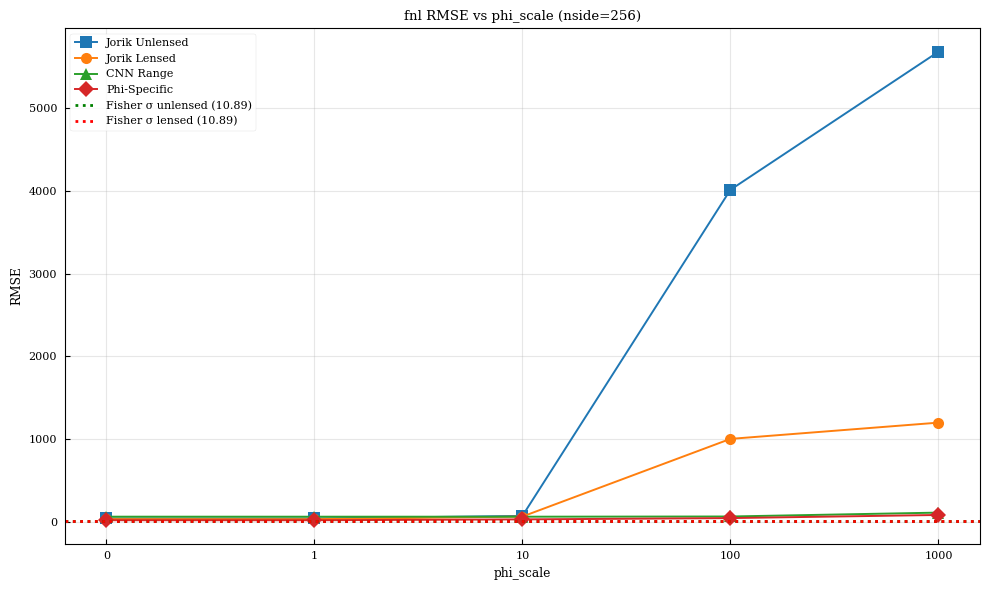

In [ ]:
# Evaluate all models at each phi_scale
impact = {"jorik_unlensed": [], "jorik_lensed": [], "cnn_range": [], "phi_specific": []}

for phi in PHI_SCALES:
    test_ds = phi_models[phi]["test_ds"]
    impact["jorik_unlensed"].append(
        evaluate_model(jorik_unlensed, test_u if phi == 0 else test_ds)[2]
    )
    impact["jorik_lensed"].append(evaluate_model(jorik_lensed, test_ds)[2])
    impact["cnn_range"].append(evaluate_model(cnn_range, test_ds)[2])
    impact["phi_specific"].append(phi_models[phi]["rmse"])

sigma_unlensed, sigma_lensed = get_fisher_sigma(False), get_fisher_sigma(True)

# Line plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(PHI_SCALES))
for data, style, label in [
    (impact["jorik_unlensed"], "s-", "Jorik Unlensed"),
    (impact["jorik_lensed"], "o-", "Jorik Lensed"),
    (impact["cnn_range"], "^-", "CNN Range"),
    (impact["phi_specific"], "D-", "Phi-Specific"),
]:
    ax.plot(x, data, style, label=label, markersize=8)
if sigma_unlensed:
    ax.axhline(
        sigma_unlensed,
        color="green",
        ls=":",
        lw=2,
        label=f"Fisher σ unlensed ({sigma_unlensed:.2f})",
    )
if sigma_lensed:
    ax.axhline(
        sigma_lensed,
        color="red",
        ls=":",
        lw=2,
        label=f"Fisher σ lensed ({sigma_lensed:.2f})",
    )
ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set(
    xlabel="phi_scale",
    ylabel="RMSE",
    title=f"fnl RMSE vs phi_scale (nside={core.nside})",
)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

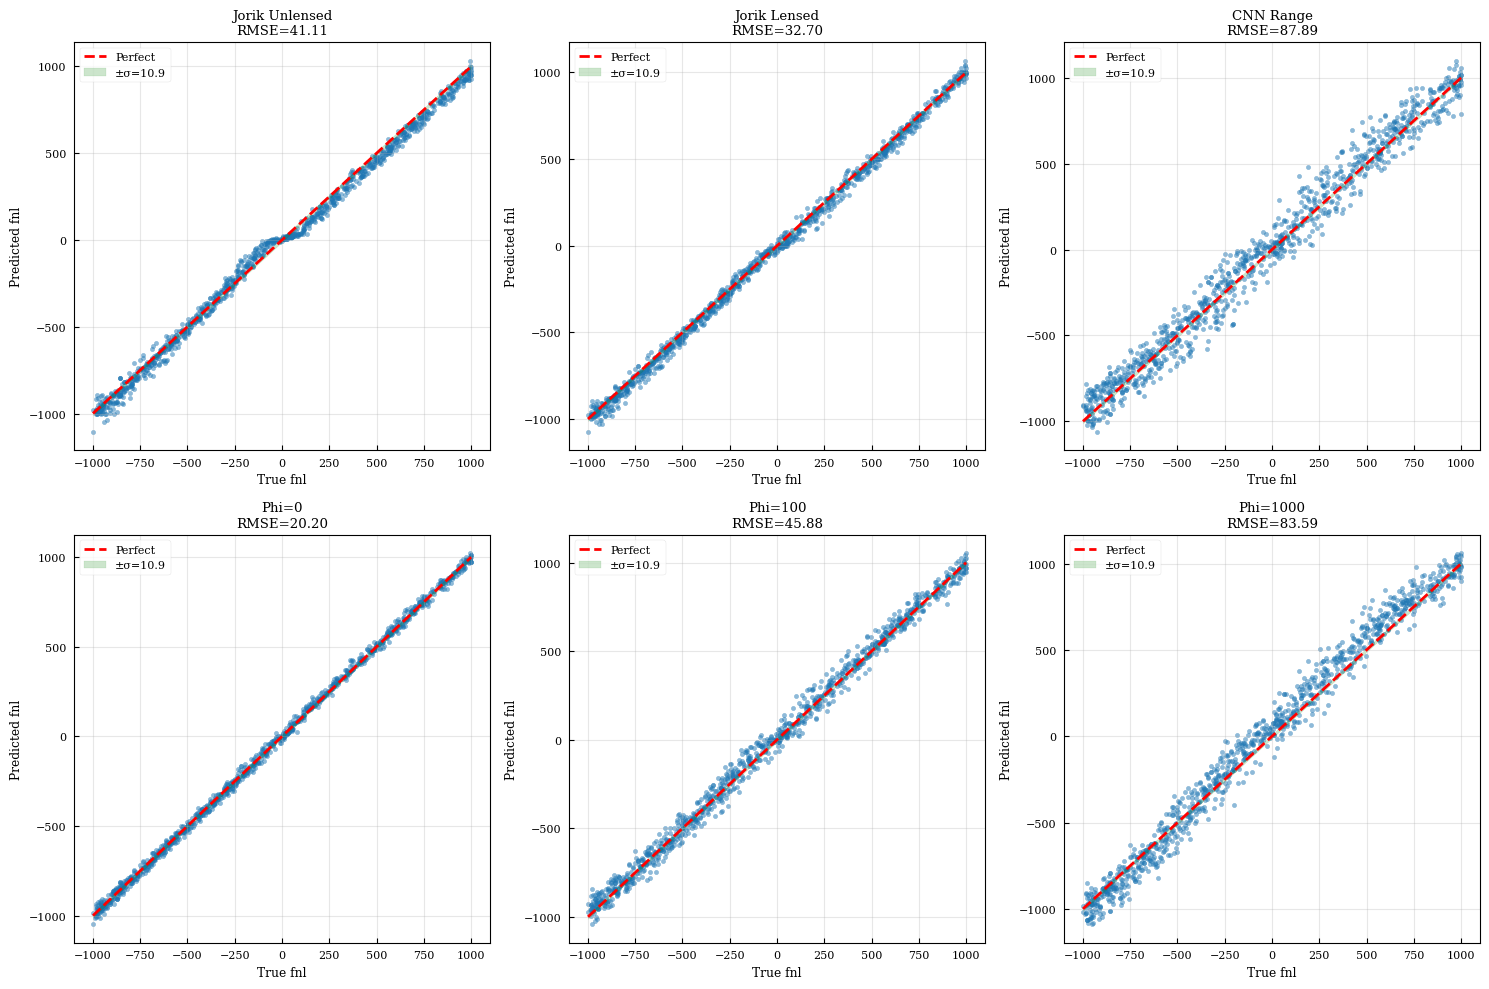

In [ ]:
# Scatter Plots: Predictions vs Truth
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sigma = sigma_lensed or 50
plot_data = [
    ("Jorik Unlensed", results["jorik_unlensed"]),
    ("Jorik Lensed", results["jorik_lensed"]),
    ("CNN Range", results["cnn_range"]),
    ("Phi=0", phi_models[0]),
    ("Phi=100", phi_models[100]),
    ("Phi=1000", phi_models[1000]),
]

for ax, (name, data) in zip(axes.flat, plot_data):
    truth, preds = data["truth"], data["preds"]
    line = np.array([np.nanmin(truth), np.nanmax(truth)])
    ax.scatter(truth, preds, alpha=0.5, s=10)
    ax.plot(line, line, "r--", lw=2, label="Perfect")
    ax.fill_between(
        line,
        line - sigma,
        line + sigma,
        alpha=0.2,
        color="green",
        label=f"±σ={sigma:.1f}",
    )
    ax.set(
        xlabel="True fnl",
        ylabel="Predicted fnl",
        title=f"{name}\nRMSE={data['rmse']:.2f}",
    )
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

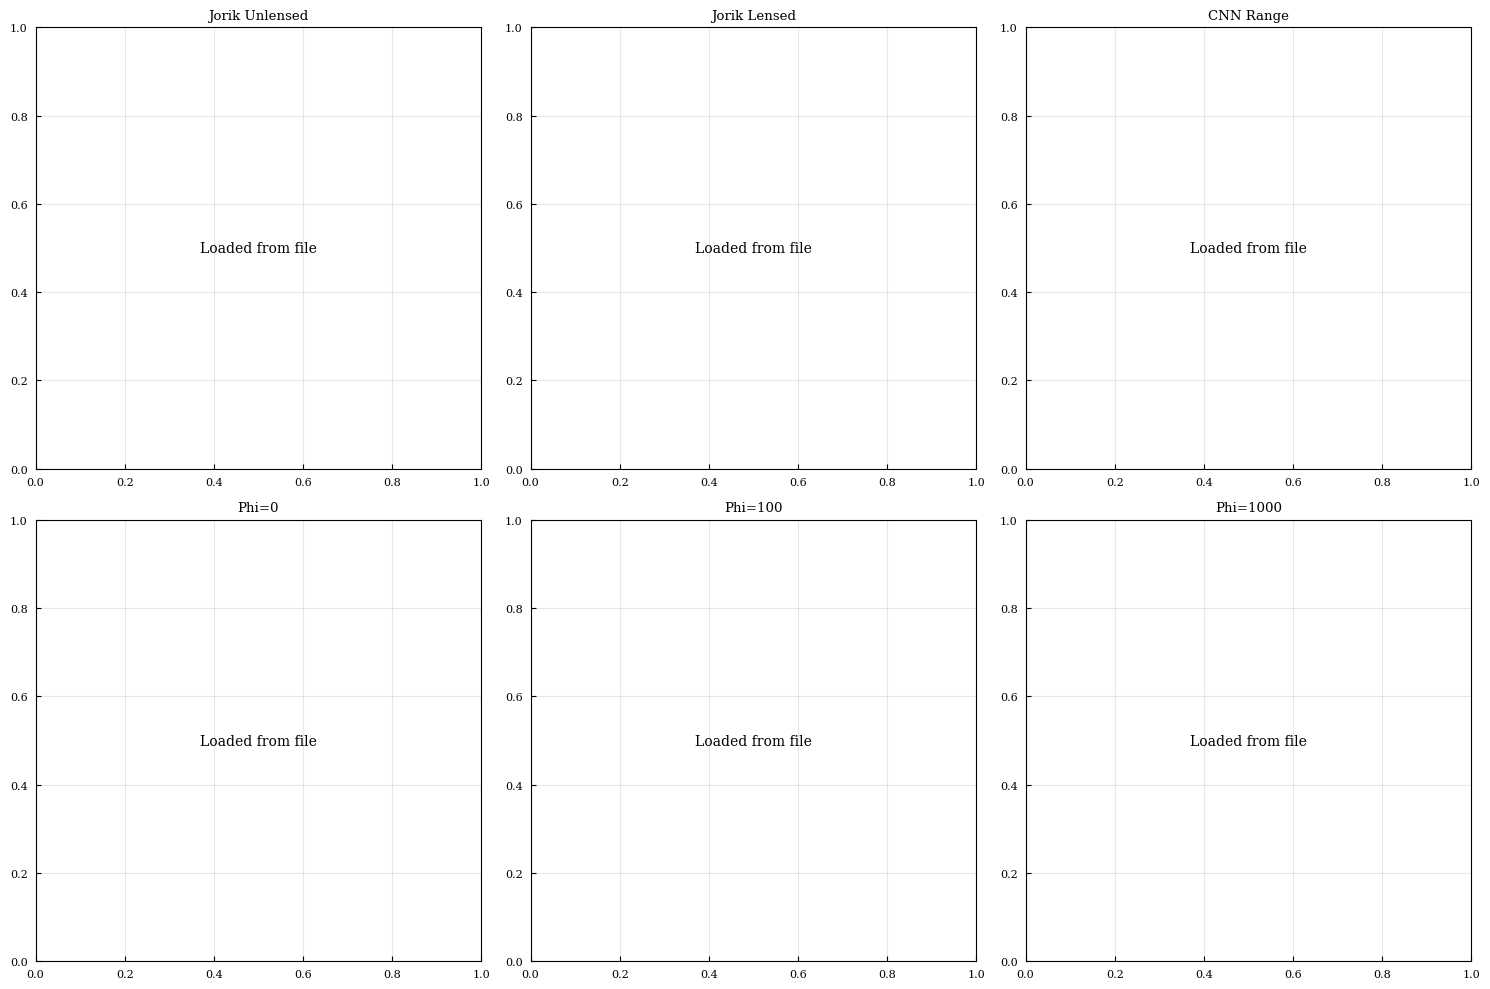

In [ ]:
# Loss Curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, data) in zip(axes.flat, plot_data):
    if data["history"]:
        ax.plot(data["history"].history["loss"], label="Train")
        ax.plot(data["history"].history["val_loss"], label="Val")
        ax.set(xlabel="Epoch", ylabel="Loss (MSE)")
        ax.legend()
    else:
        ax.text(
            0.5,
            0.5,
            "Loaded from file",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

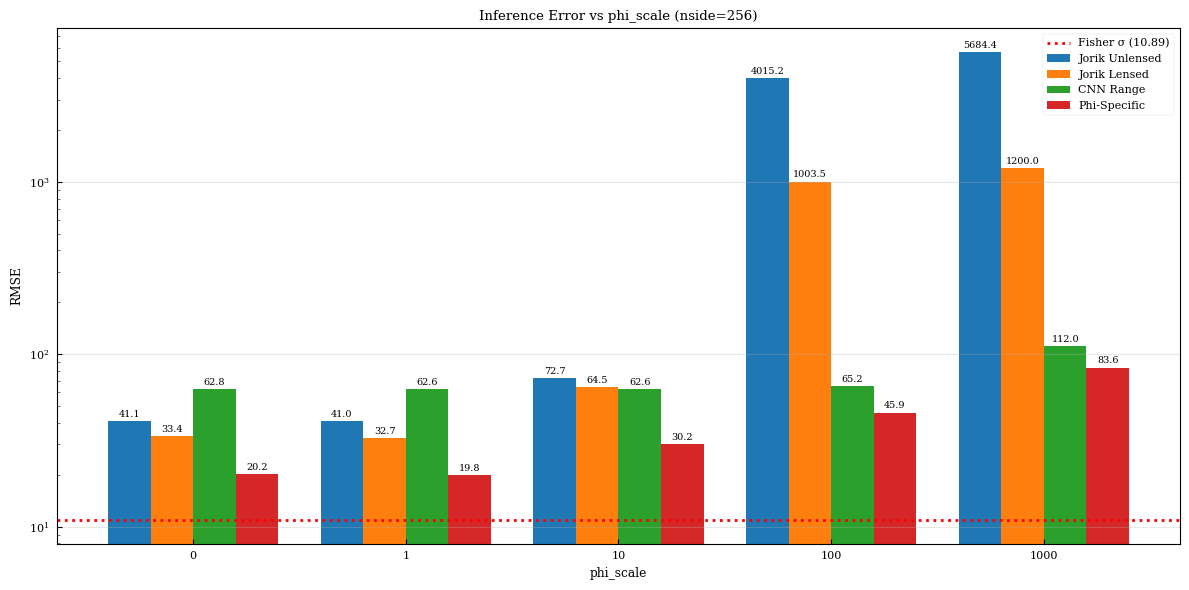

In [ ]:
# Inference Error vs Phi-Scale (Bar Plot)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(PHI_SCALES))
width = 0.2
labels = ["Jorik Unlensed", "Jorik Lensed", "CNN Range", "Phi-Specific"]
colors = plt.cm.tab10.colors[:4]

for i, (key, label) in enumerate(
    zip(["jorik_unlensed", "jorik_lensed", "cnn_range", "phi_specific"], labels)
):
    bars = ax.bar(
        x + (i - 1.5) * width, impact[key], width, label=label, color=colors[i]
    )
    for bar in bars:
        ax.annotate(
            f"{bar.get_height():.1f}",
            xy=(bar.get_x() + width / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )
if sigma_lensed:
    ax.axhline(
        sigma_lensed, color="red", ls=":", lw=2, label=f"Fisher σ ({sigma_lensed:.2f})"
    )
ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set(
    xlabel="phi_scale",
    ylabel="RMSE",
    title=f"Inference Error vs phi_scale (nside={core.nside})",
)
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

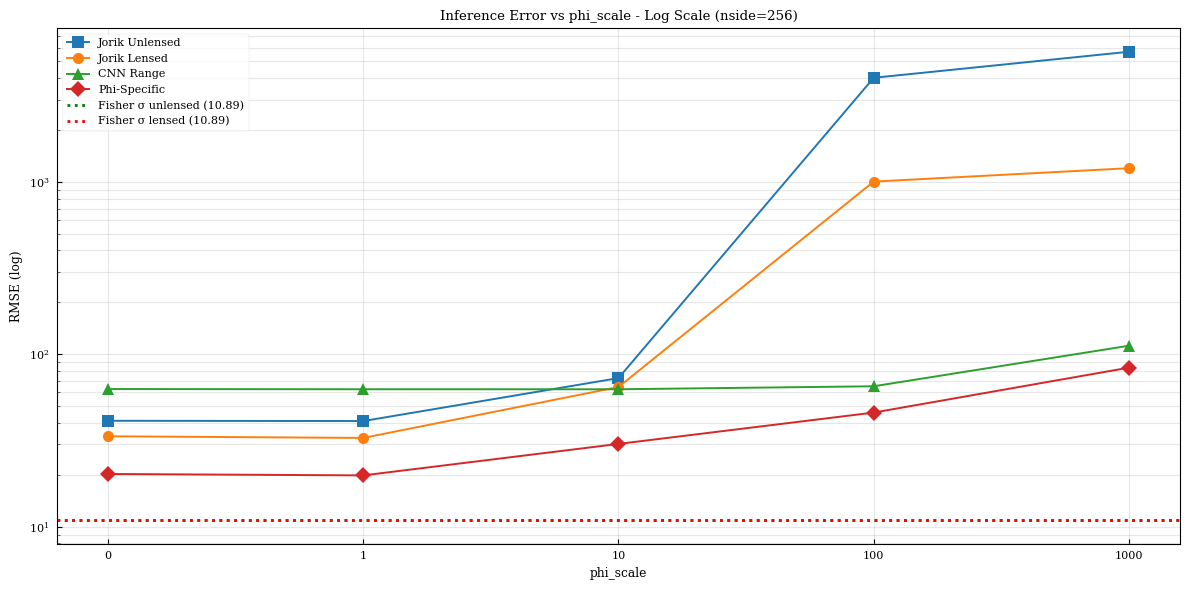

In [ ]:
# Inference Error vs Phi-Scale (Log Line Plot)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(PHI_SCALES))
labels = ["Jorik Unlensed", "Jorik Lensed", "CNN Range", "Phi-Specific"]
colors = plt.cm.tab10.colors[:4]

for key, label, color, marker in zip(
    ["jorik_unlensed", "jorik_lensed", "cnn_range", "phi_specific"],
    labels,
    colors,
    ["s", "o", "^", "D"],
):
    ax.plot(x, impact[key], marker=marker, label=label, color=color, markersize=8)
if sigma_unlensed:
    ax.axhline(
        sigma_unlensed,
        color="green",
        ls=":",
        lw=2,
        label=f"Fisher σ unlensed ({sigma_unlensed:.2f})",
    )
if sigma_lensed:
    ax.axhline(
        sigma_lensed,
        color="red",
        ls=":",
        lw=2,
        label=f"Fisher σ lensed ({sigma_lensed:.2f})",
    )
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set(
    xlabel="phi_scale",
    ylabel="RMSE (log)",
    title=f"Inference Error vs phi_scale - Log Scale (nside={core.nside})",
)
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [ ]:
# Summary Table
print("\nSummary: Model Performance")
print("=" * 70)
print(f"{'Model':<20} {'RMSE':<10} {'MAE':<10} {'Time (s)':<10} {'Val Loss':<12}")
print("-" * 70)

for name, data in [
    ("Jorik Unlensed", results["jorik_unlensed"]),
    ("Jorik Lensed", results["jorik_lensed"]),
    ("CNN Range", results["cnn_range"]),
]:
    val_loss = (
        f"{min(data['history'].history['val_loss']):.6f}" if data["history"] else "N/A"
    )
    print(
        f"{name:<20} {data['rmse']:<10.4f} {data['mae']:<10.4f} {data['time']:<10.1f} {val_loss:<12}"
    )

for phi in PHI_SCALES:
    data = phi_models[phi]
    val_loss = (
        f"{min(data['history'].history['val_loss']):.6f}" if data["history"] else "N/A"
    )
    print(
        f"{'Phi=' + str(phi):<20} {data['rmse']:<10.4f} {data['mae']:<10.4f} {data['time']:<10.1f} {val_loss:<12}"
    )

print("=" * 70)
if sigma_unlensed:
    print(f"Fisher σ (unlensed): {sigma_unlensed:.4f}")
if sigma_lensed:
    print(f"Fisher σ (lensed): {sigma_lensed:.4f}")


Summary: Model Performance
Model                RMSE       MAE        Time (s)   Val Loss    
----------------------------------------------------------------------
Jorik Unlensed       41.1140    33.6951    0.0        N/A         
Jorik Lensed         32.6952    25.7934    0.0        N/A         
CNN Range            87.8870    70.8990    0.0        N/A         
Phi=0                20.2047    15.9983    0.0        N/A         
Phi=1                19.8214    15.7701    0.0        N/A         
Phi=10               30.1839    24.1130    0.0        N/A         
Phi=100              45.8780    36.1987    0.0        N/A         
Phi=1000             83.5917    67.1772    0.0        N/A         
Fisher σ (unlensed): 10.8899
Fisher σ (lensed): 10.8898


## Fisher + δ⟨N²⟩ Minimum Variance Calculation

In [ ]:
# Initialize CAMB and compute power spectra (following ksw/cosmo.py compute_transfer pattern)
import camb
import vegas
import numba
from math import sqrt
from scipy.interpolate import interp1d
from scipy.special import spherical_jn
from joblib import Parallel, delayed

# Setup CAMB with core's cosmological parameters
camb_lmax = core.lmax
camb_params = camb.set_params(**core.cosmo_params)

# Get transfer functions first (before calling get_results for power spectra)
transfer_data = camb.get_transfer_functions(camb_params)
tr = transfer_data.get_cmb_transfer_data("scalar")

# Get the transfer function arrays (note: L is uppercase in CAMB API)
tr_ells = tr.L.astype(np.int32)
tr_k = tr.q.astype(np.float64)  # Keep k in float64 for precision

# Apply E-mode prefactor (ksw/cosmo.py pattern)
# Modify scalar E-mode, see Zaldarriaga 1997 Eqs. 18 and 39.
# Note: prefactor uses ells (not tr_ells)
ells = np.arange(len(tr_ells))
prefactor = np.sqrt((ells + 2) * (ells + 1) * ells * (ells - 1))
tr.delta_p_l_k[1, ...] *= prefactor[:, np.newaxis]

# Scale with CMB temperature in uK
tr.delta_p_l_k *= camb_params.TCMB * 1e6

# Transfer function is now of shape (NumSources, nell, nk)
# NumSources = 3 (T, E, lensing potential)
# We want shape (nell, nk, npol=2) for T and E
nk = tr.q.size
nell = tr_ells.size
npol = 2
tr_ell_k = np.empty((nell, nk, npol), dtype=np.float32)

tr_view = tr.delta_p_l_k[:2, ...]  # Get T and E only
tr_view = np.swapaxes(tr_view, 0, 2)  # (nk, nell, npol)
tr_view = np.swapaxes(tr_view, 0, 1)  # (nell, nk, npol)
tr_ell_k[:] = np.ascontiguousarray(tr_view).astype(np.float32)

# For local fnl bispectrum, we only need T mode - extract it
tr_ell_k_T = tr_ell_k[:, :, 0]  # (nell, nk) - Temperature only

# Convert from zeta to phi (CAMB returns zeta)
tr_ell_k_T = (tr_ell_k_T * np.float32(5 / 3)).astype(np.float32)

# Now compute power spectra
transfer_data.power_spectra_from_transfer()
c_ell_unlensed = transfer_data.get_unlensed_scalar_cls(
    lmax=core.nell, CMB_unit="muK", raw_cl=True
)
c_ell_lensed = transfer_data.get_lensed_scalar_cls(
    lmax=core.nell, CMB_unit="muK", raw_cl=True
)
c_ell_lenspotential = transfer_data.get_lens_potential_cls(
    lmax=core.nell, CMB_unit="muK", raw_cl=True
)

# Extract TT power spectra
c_ell_camb = c_ell_unlensed[: core.nell, 0].astype(np.float32)  # TT unlensed
c_ell_lens_camb = c_ell_lensed[: core.nell, 0].astype(np.float32)  # TT lensed
cl_phi_camb = c_ell_lenspotential[: core.nell, 0].astype(np.float32)  # C_ell^phiphi

print(f"CAMB initialized: lmax={camb_lmax}")
print(f"  Transfer: len(tr_k)={len(tr_k)}, len(tr_ells)={len(tr_ells)}")
print(f"  tr_ell_k shape: {tr_ell_k.shape}, tr_ell_k_T shape: {tr_ell_k_T.shape}")
print(f"  Power spectra shapes: c_ell={c_ell_camb.shape}, cl_phi={cl_phi_camb.shape}")

CAMB initialized: lmax=767
  Transfer: len(tr_k)=1290, len(tr_ells)=56
  tr_ell_k shape: (56, 1290, 2), tr_ell_k_T shape: (56, 1290)
  Power spectra shapes: c_ell=(768,), cl_phi=(768,)


In [ ]:
# Compute radial functions alpha_l and beta_l using direct spherical Bessel integration
# f_ell(r) = (2/pi) * int dk k^2 f(k) Delta_ell(k) j_ell(k*r)


def compute_radial_for_single_radius(
    r_idx, radius, tr_ell_k_T, tr_k, tr_ells, f_k_alpha, f_k_beta
):
    """
    Compute alpha_ell(r) and beta_ell(r) for a single radius using trapezoidal integration.

    alpha_ell(r) = (2/pi) * int dk k^2 * 1 * Delta_ell(k) * j_ell(k*r)
    beta_ell(r)  = (2/pi) * int dk k^2 * f_beta(k) * Delta_ell(k) * j_ell(k*r)
    """
    nell = len(tr_ells)
    alpha_ell = np.zeros(nell, dtype=np.float32)
    beta_ell = np.zeros(nell, dtype=np.float32)

    # Precompute k^2 * dk weights (trapezoidal)
    dk = np.zeros_like(tr_k)
    dk[0] = 0.5 * (tr_k[1] - tr_k[0])
    dk[1:-1] = 0.5 * (tr_k[2:] - tr_k[:-2])
    dk[-1] = 0.5 * (tr_k[-1] - tr_k[-2])
    weights = (2.0 / np.pi) * tr_k**2 * dk

    for i_ell, ell in enumerate(tr_ells):
        if ell < 2:
            continue

        # Compute spherical Bessel function j_ell(k*r)
        kr = tr_k * radius
        # Limit kr to avoid overflow in spherical_jn
        mask = kr < 1e4
        jl = np.zeros_like(kr, dtype=np.float32)
        if np.any(mask):
            jl[mask] = spherical_jn(int(ell), kr[mask]).astype(np.float32)

        # Get transfer function for this ell (Temperature only)
        delta_ell = tr_ell_k_T[i_ell, :]

        # Integrate
        integrand_alpha = weights * f_k_alpha * delta_ell * jl
        integrand_beta = weights * f_k_beta * delta_ell * jl

        alpha_ell[i_ell] = np.sum(integrand_alpha).astype(np.float32)
        beta_ell[i_ell] = np.sum(integrand_beta).astype(np.float32)

    return alpha_ell, beta_ell


# Compute primordial power spectrum P(k)
Pk = camb_params.primordial_power(tr_k, 0).astype(np.float32)
delta_phi = (2 * np.pi**2 * Pk * (3 / 5) ** 2).astype(np.float32)

# f_k for alpha (just 1) and beta (delta_phi * k^-3)
f_k_alpha = np.ones_like(tr_k, dtype=np.float32)
f_k_beta = (delta_phi * tr_k ** (-3)).astype(np.float32)

print(f"Computing radial functions for {len(core.radii)} radii using joblib...")
print(f"  tr_ell_k_T shape: {tr_ell_k_T.shape}")

# Use joblib to parallelize radial function computation
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(compute_radial_for_single_radius)(
        i, r, tr_ell_k_T, tr_k, tr_ells, f_k_alpha, f_k_beta
    )
    for i, r in enumerate(core.radii)
)

# Stack results into arrays
alpha_ell_raw = np.array(
    [r[0] for r in results], dtype=np.float32
)  # (n_radii, n_tr_ells)
beta_ell_raw = np.array([r[1] for r in results], dtype=np.float32)

# Interpolate to target ells (core.ells)
alpha_l = interp1d(
    tr_ells, alpha_ell_raw, kind="cubic", axis=1, bounds_error=False, fill_value=0
)(core.ells).astype(np.float32)

beta_l = interp1d(
    tr_ells, beta_ell_raw, kind="cubic", axis=1, bounds_error=False, fill_value=0
)(core.ells).astype(np.float32)

print(f"alpha_l shape: {alpha_l.shape}, beta_l shape: {beta_l.shape}")
print(f"  alpha_l dtype: {alpha_l.dtype}, beta_l dtype: {beta_l.dtype}")

Computing radial functions for 1200 radii using joblib...
  tr_ell_k_T shape: (56, 1290)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    2.3s finished
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 614 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 614 tasks      | elapsed:    4.2s


alpha_l shape: (1200, 768), beta_l shape: (1200, 768)
  alpha_l dtype: float32, beta_l dtype: float32


[Parallel(n_jobs=-1)]: Done 1200 out of 1200 | elapsed:    5.6s finished


In [ ]:
# Numba helper functions for bispectrum and trispectrum calculations (float32)
# Following lens_test.ipynb functions


@numba.njit(nogil=True, fastmath=False)
def numba_trapezoid(y, x):
    """Trapezoidal integration for float32 arrays."""
    n = len(x)
    integral = np.float32(0.0)
    for i in range(1, n):
        integral += (x[i] - x[i - 1]) * (y[i] + y[i - 1]) * np.float32(0.5)
    return integral


@numba.njit(nogil=True, fastmath=False)
def compute_bispectrum_local(alpha, beta, l1, l2, l3, rs):
    """Compute local bispectrum B_l1l2l3."""
    n = len(rs)
    integrand = np.empty(n, dtype=np.float32)
    for i in range(n):
        r_sq = rs[i] * rs[i]
        integrand[i] = r_sq * (
            beta[l3, i] * beta[l2, i] * alpha[l1, i]
            + beta[l1, i] * beta[l3, i] * alpha[l2, i]
            + beta[l2, i] * beta[l1, i] * alpha[l3, i]
        )
    return np.float32(6.0 / 5.0) * numba_trapezoid(integrand, rs)


@numba.njit(nogil=True, fastmath=False)
def compute_W(l1, l2, l3, c_ell, radii, alpha, beta):
    """Compute weight function W_l1l2l3."""
    C6 = np.float32(6.0) * c_ell[l1] * c_ell[l2] * c_ell[l3]
    if C6 == np.float32(0.0):
        return np.float32(0.0)
    B = compute_bispectrum_local(alpha, beta, l1, l2, l3, radii)
    return np.float32(4) * np.float32(np.pi * np.pi) * B / C6


@numba.njit(nogil=True, fastmath=False)
def tri_single(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    """Single term of lensing trispectrum."""
    l13_0 = l1_0 + l3_0
    l13_1 = l1_1 + l3_1
    l24_0 = l2_0 + l4_0
    l24_1 = l2_1 + l4_1

    l13_mag = int(round(sqrt(l13_0 * l13_0 + l13_1 * l13_1)))
    l3_mag = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    l4_mag = int(round(sqrt(l4_0 * l4_0 + l4_1 * l4_1)))

    if not (2 < l3_mag <= lmax and 2 < l4_mag <= lmax and 2 < l13_mag <= lmax):
        return np.float32(0.0)

    l13_3 = l13_0 * l3_0 + l13_1 * l3_1
    l24_4 = l24_0 * l4_0 + l24_1 * l4_1
    return (
        c_ell_phi[l13_mag] * c_ell[l3_mag] * c_ell[l4_mag] * np.float32(l13_3 * l24_4)
    )


@numba.njit(nogil=True, fastmath=False)
def tri(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    """Full lensing trispectrum with all 24 permutations."""
    value = np.float32(0.0)
    # All 24 permutations of (l1, l2, l3, l4)
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1, l2_0, l2_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1, l1_0, l1_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l1_0, l1_1, l2_0, l2_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l2_0, l2_1, l1_0, l1_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l4_0, l4_1, l2_0, l2_1, l1_0, l1_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l2_0, l2_1, l1_0, l1_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l3_0, l3_1, l1_0, l1_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l3_0, l3_1, l2_0, l2_1, l1_0, l1_1
    )

    return value * np.float32(0.5)

In [ ]:
# Delta N^2 integrand and Vegas integration (float32 compatible)


@numba.njit(nogil=True, fastmath=False)
def delta_n2_integrand_scalar(x, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
    """Scalar integrand for delta<N^2> computation."""
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    lp2_0, lp2_1 = x[4], x[5]

    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1
    lp1_0, lp1_1 = -l1_0, -l1_1
    lp3_0, lp3_1 = -l2_0 - l3_0 - lp2_0, -l2_1 - l3_1 - lp2_1

    lm = lmax
    if not (
        -lm <= l3_0 <= lm
        and -lm <= l3_1 <= lm
        and -lm <= lp1_0 <= lm
        and -lm <= lp1_1 <= lm
        and -lm <= lp3_0 <= lm
        and -lm <= lp3_1 <= lm
    ):
        return np.float32(0.0)

    l1 = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2 = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3 = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    lp1 = int(round(sqrt(lp1_0 * lp1_0 + lp1_1 * lp1_1)))
    lp2 = int(round(sqrt(lp2_0 * lp2_0 + lp2_1 * lp2_1)))
    lp3 = int(round(sqrt(lp3_0 * lp3_0 + lp3_1 * lp3_1)))

    if not (
        2 < l1 <= lmax
        and 2 < l2 <= lmax
        and 2 < l3 <= lmax
        and 2 < lp1 <= lmax
        and 2 < lp2 <= lmax
        and 2 < lp3 <= lmax
    ):
        return np.float32(0.0)

    W = compute_W(l1, l2, l3, c_ell, radii, alpha, beta)
    Wp = compute_W(lp1, lp2, lp3, c_ell, radii, alpha, beta)
    T = tri(lmax, c_ell, cl_phi, l2_0, l2_1, l3_0, l3_1, lp2_0, lp2_1, lp3_0, lp3_1)
    return W * Wp * c_ell_lens[l1] * T


@numba.njit(parallel=True, nogil=True, fastmath=False)
def delta_n2_integrand_batch(
    x_batch, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii
):
    """Batch integrand for delta<N^2> with parallel execution."""
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float32)
    for i in numba.prange(n):
        out[i] = delta_n2_integrand_scalar(
            x_batch[i], lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii
        )
    return out


class DeltaN2IntegrandNumbaVec(vegas.LBatchIntegrand):
    """Vegas batch integrand for delta<N^2>."""

    def __init__(self, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell.astype(np.float32)
        self.c_ell_lens = c_ell_lens.astype(np.float32)
        self.cl_phi = cl_phi.astype(np.float32)
        self.alpha = alpha.astype(np.float32)
        self.beta = beta.astype(np.float32)
        self.radii = radii.astype(np.float32)

    def __call__(self, x):
        return delta_n2_integrand_batch(
            x.astype(np.float32),
            self.lmax,
            self.c_ell,
            self.c_ell_lens,
            self.cl_phi,
            self.alpha,
            self.beta,
            self.radii,
        )


def compute_delta_N2(
    c_ell, c_ell_lens, cl_phi, alpha_l, beta_l, radii, lmax, neval=1e7, nitn=(10, 10)
):
    """Compute delta<N^2> using Vegas integration."""
    integrand = DeltaN2IntegrandNumbaVec(
        lmax, c_ell, c_ell_lens, cl_phi, alpha_l.T, beta_l.T, radii
    )

    integ = vegas.Integrator([[-lmax, lmax]] * 6, neval=int(neval))
    integ(integrand, nitn=nitn[0], neval=int(neval))
    result = integ(integrand, nitn=nitn[1], neval=int(neval))
    norm = np.float32(9.0 / (2 * np.pi) ** 8 / np.pi)
    return norm * np.float32(result.mean), result

In [ ]:
# Compute delta<N^2> and combined Fisher + δ⟨N²⟩ bound for each phi_scale
# σ_total = √(σ_Fisher² + δ⟨N²⟩) - variance is additive
delta_n2_values = {}
fisher_delta_n2_rmse = []

for phi_scale in PHI_SCALES:
    if phi_scale == 0:
        dn2 = np.float32(0.0)
        sigma_base = sigma_unlensed or sigma_lensed
    else:
        cl_phi_scaled = (cl_phi_camb * (phi_scale**2)).astype(np.float32)
        dn2, _ = compute_delta_N2(
            c_ell_camb,
            c_ell_lens_camb,
            cl_phi_scaled,
            alpha_l,
            beta_l,
            core.radii.astype(np.float32),
            lmax=core.lmax,
            neval=1e7,
        )
        sigma_base = sigma_lensed or sigma_unlensed

    delta_n2_values[phi_scale] = dn2
    # TODO: make sqrt(simga^2 + delta n^2 / s^2)
    sigma_comb = (sigma_base + float(dn2)) if sigma_base else np.nan
    fisher_delta_n2_rmse.append(float(sigma_comb))
    print(
        f"phi={phi_scale}: σ_Fisher={sigma_base:.2f}, δ⟨N²⟩={dn2:.2e}, σ_total={sigma_comb:.2f}"
    )

phi=0: σ_Fisher=10.89, δ⟨N²⟩=0.00e+00, σ_total=10.89
phi=1: σ_Fisher=10.89, δ⟨N²⟩=1.28e-05, σ_total=10.89
phi=10: σ_Fisher=10.89, δ⟨N²⟩=1.28e-03, σ_total=10.89
phi=100: σ_Fisher=10.89, δ⟨N²⟩=1.28e-01, σ_total=11.02
phi=1000: σ_Fisher=10.89, δ⟨N²⟩=1.28e+01, σ_total=23.65


## Comparison Plots with Fisher + δ⟨N²⟩ Bound

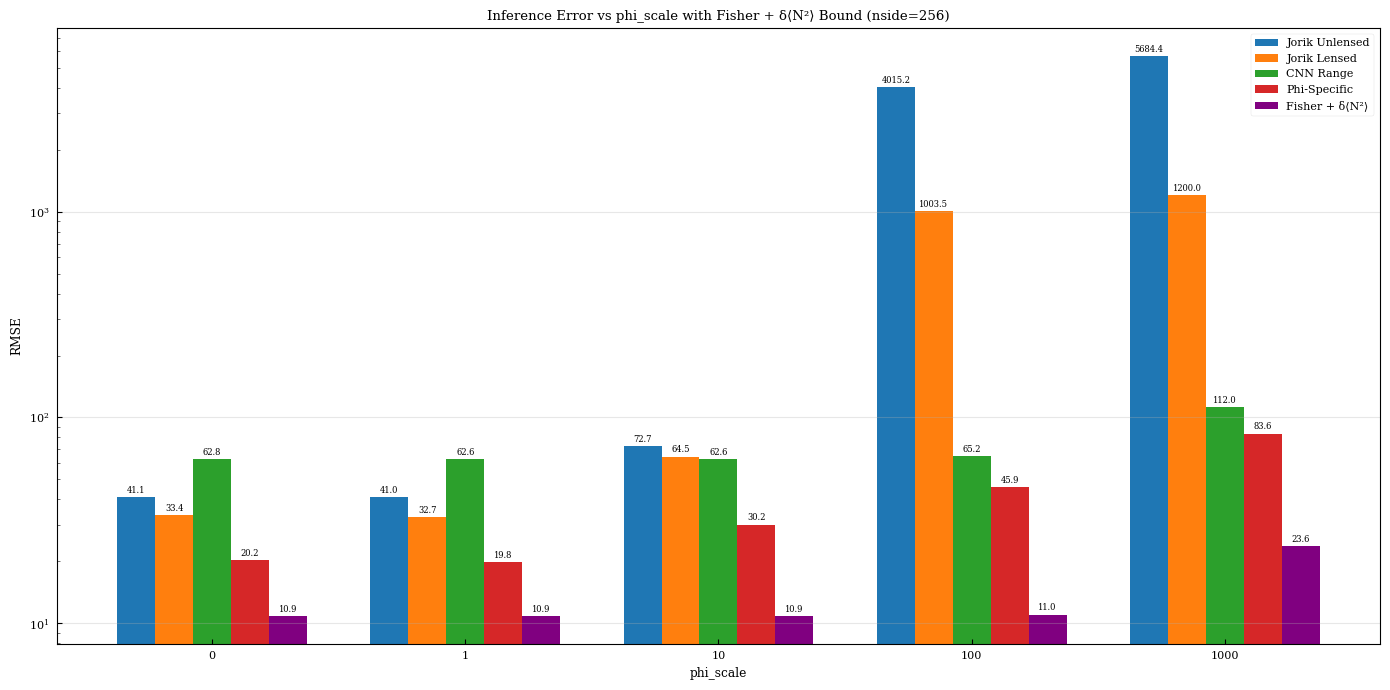

In [ ]:
# Inference Error vs Phi-Scale (Bar Plot with Fisher + δ⟨N²⟩)
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(PHI_SCALES))
width = 0.15  # Narrower bars for 5 groups
labels = [
    "Jorik Unlensed",
    "Jorik Lensed",
    "CNN Range",
    "Phi-Specific",
    "Fisher + δ⟨N²⟩",
]
colors = list(plt.cm.tab10.colors[:4]) + ["purple"]

keys = ["jorik_unlensed", "jorik_lensed", "cnn_range", "phi_specific"]
values = [impact[k] for k in keys] + [fisher_delta_n2_rmse]

for i, (vals, label, color) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + (i - 2) * width, vals, width, label=label, color=color)
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(
                f"{height:.1f}",
                xy=(bar.get_x() + width / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                fontsize=6,
            )

ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set(
    xlabel="phi_scale",
    ylabel="RMSE",
    title=f"Inference Error vs phi_scale with Fisher + δ⟨N²⟩ Bound (nside={core.nside})",
)
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

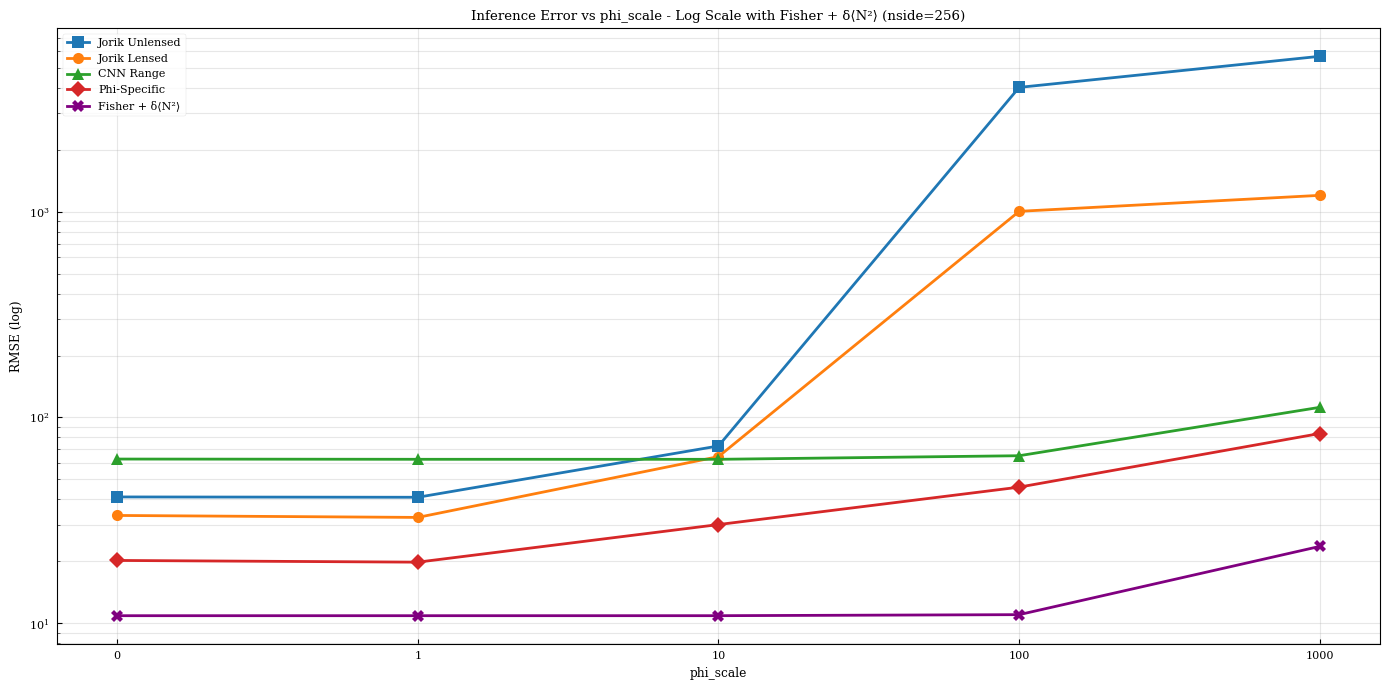

In [ ]:
# Inference Error vs Phi-Scale (Log Line Plot with Fisher + δ⟨N²⟩)
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(PHI_SCALES))
labels = [
    "Jorik Unlensed",
    "Jorik Lensed",
    "CNN Range",
    "Phi-Specific",
    "Fisher + δ⟨N²⟩",
]
colors = list(plt.cm.tab10.colors[:4]) + ["purple"]
markers = ["s", "o", "^", "D", "X"]

keys = ["jorik_unlensed", "jorik_lensed", "cnn_range", "phi_specific"]
values = [impact[k] for k in keys] + [fisher_delta_n2_rmse]

for vals, label, color, marker in zip(values, labels, colors, markers):
    ax.plot(x, vals, marker=marker, label=label, color=color, markersize=8, linewidth=2)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set(
    xlabel="phi_scale",
    ylabel="RMSE (log)",
    title=f"Inference Error vs phi_scale - Log Scale with Fisher + δ⟨N²⟩ (nside={core.nside})",
)
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()